In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv("iris.csv")

df = df.drop("species", axis=1)

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [2]:
def train_test_split(X, y, test_size=0.2):
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    
    split = int(len(X) * (1 - test_size))
    
    train_idx = indices[:split]
    test_idx = indices[split:]
    
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

X_train, X_test, y_train, y_test = train_test_split(X, y)

In [3]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

In [8]:
def knn_predict(X_train, y_train, X_test, k):
    predictions = []
    
    for test_point in X_test:
        distances = []
        
        for i in range(len(X_train)):
            dist = euclidean_distance(test_point, X_train[i])
            distances.append((dist, y_train[i]))
        
        distances.sort(key=lambda x: x[0])
        
        neighbors = distances[:k]
        
        labels = np.array([label for _, label in neighbors])
        
        counts = np.bincount(labels.astype(int))
        prediction = np.argmax(counts)
        
        predictions.append(prediction)
    
    return np.array(predictions)

In [9]:
def accuracy(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)

In [10]:
k_values = [1, 3, 5, 7, 9]

for k in k_values:
    preds = knn_predict(X_train, y_train, X_test, k)
    acc = accuracy(y_test, preds)
    print("K =", k, "Accuracy =", acc)

K = 1 Accuracy = 0.06666666666666667
K = 3 Accuracy = 0.06666666666666667
K = 5 Accuracy = 0.06666666666666667
K = 7 Accuracy = 0.06666666666666667
K = 9 Accuracy = 0.06666666666666667


In [11]:
def weighted_knn_predict(X_train, y_train, X_test, k):
    predictions = []
    
    for test_point in X_test:
        distances = []
        
        for i in range(len(X_train)):
            dist = euclidean_distance(test_point, X_train[i])
            distances.append((dist, y_train[i]))
        
        distances.sort(key=lambda x: x[0])
        
        neighbors = distances[:k]
        
        class_weights = {}
        
        for dist, label in neighbors:
            weight = 1 / (dist + 1e-5)
            
            if label not in class_weights:
                class_weights[label] = 0
            
            class_weights[label] += weight
        
        prediction = max(class_weights, key=class_weights.get)
        
        predictions.append(prediction)
    
    return np.array(predictions)

In [12]:
for k in k_values:
    preds = weighted_knn_predict(X_train, y_train, X_test, k)
    acc = accuracy(y_test, preds)
    print("Weighted K =", k, "Accuracy =", acc)

Weighted K = 1 Accuracy = 0.2
Weighted K = 3 Accuracy = 0.23333333333333334
Weighted K = 5 Accuracy = 0.16666666666666666
Weighted K = 7 Accuracy = 0.23333333333333334
Weighted K = 9 Accuracy = 0.26666666666666666


In [13]:
def initialize_centroids(X, k):
    indices = np.random.choice(len(X), k, replace=False)
    return X[indices]

In [14]:
def assign_clusters(X, centroids):
    clusters = []
    
    for point in X:
        distances = [euclidean_distance(point, c) for c in centroids]
        cluster = np.argmin(distances)
        clusters.append(cluster)
    
    return np.array(clusters)

In [15]:
def update_centroids(X, clusters, k):
    centroids = []
    
    for i in range(k):
        points = X[clusters == i]
        centroids.append(np.mean(points, axis=0))
    
    return np.array(centroids)

In [16]:
def kmeans(X, k, iterations=100):
    centroids = initialize_centroids(X, k)
    
    for _ in range(iterations):
        clusters = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, clusters, k)
        
        if np.all(centroids == new_centroids):
            break
        
        centroids = new_centroids
    
    return clusters

In [17]:
def kmeans_accuracy(X, y, k):
    clusters = kmeans(X, k)
    
    labels = np.zeros(k)
    
    for i in range(k):
        points = y[clusters == i]
        if len(points) == 0:
            continue
        labels[i] = np.bincount(points.astype(int)).argmax()
    
    predictions = np.array([labels[c] for c in clusters])
    
    return accuracy(y, predictions)

In [18]:
for k in [2, 3, 4, 5]:
    acc = kmeans_accuracy(X, y, k)
    print("K-Means K =", k, "Accuracy =", acc)

K-Means K = 2 Accuracy = 0.03333333333333333
K-Means K = 3 Accuracy = 0.07333333333333333
K-Means K = 4 Accuracy = 0.06
K-Means K = 5 Accuracy = 0.07333333333333333


In [19]:
knn_acc = []
weighted_knn_acc = []

k_values = [1, 3, 5, 7, 9]

for k in k_values:
    preds = knn_predict(X_train, y_train, X_test, k)
    acc = accuracy(y_test, preds)
    knn_acc.append(acc)

    preds_w = weighted_knn_predict(X_train, y_train, X_test, k)
    acc_w = accuracy(y_test, preds_w)
    weighted_knn_acc.append(acc_w)

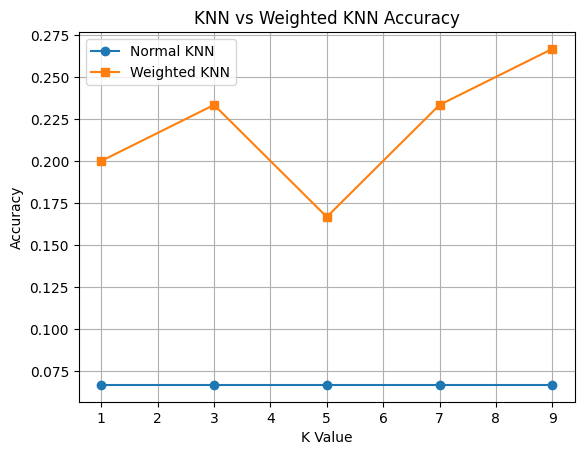

In [20]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(k_values, knn_acc, marker='o', label='Normal KNN')
plt.plot(k_values, weighted_knn_acc, marker='s', label='Weighted KNN')

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN vs Weighted KNN Accuracy")

plt.legend()
plt.grid()

plt.show()

In [21]:
kmeans_k = [2, 3, 4, 5]
kmeans_acc = []

for k in kmeans_k:
    acc = kmeans_accuracy(X, y, k)
    kmeans_acc.append(acc)

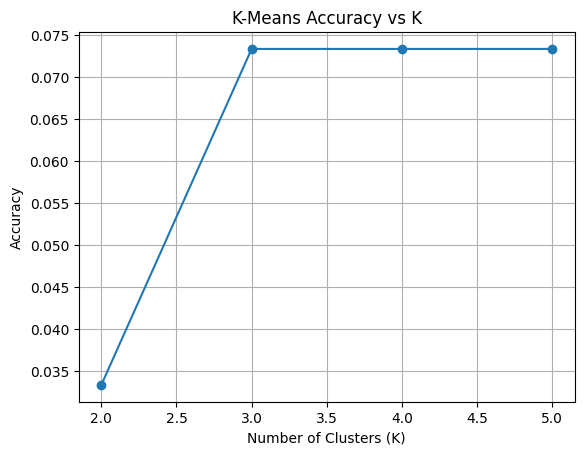

In [22]:
plt.figure()

plt.plot(kmeans_k, kmeans_acc, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Accuracy")
plt.title("K-Means Accuracy vs K")

plt.grid()

plt.show()

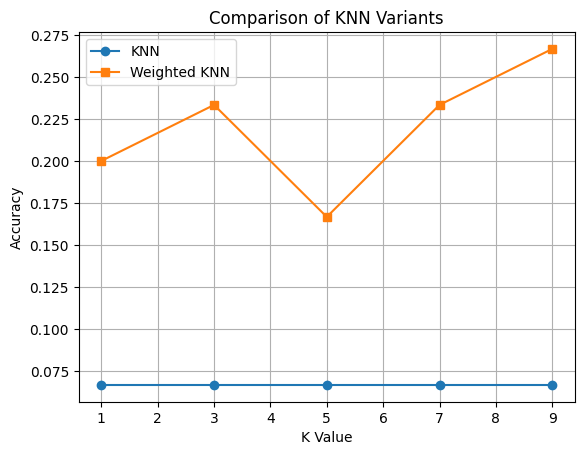

In [23]:
plt.figure()

plt.plot(k_values, knn_acc, marker='o', label='KNN')
plt.plot(k_values, weighted_knn_acc, marker='s', label='Weighted KNN')

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Comparison of KNN Variants")

plt.legend()
plt.grid()

plt.show()